In [26]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_session(quiet=True)

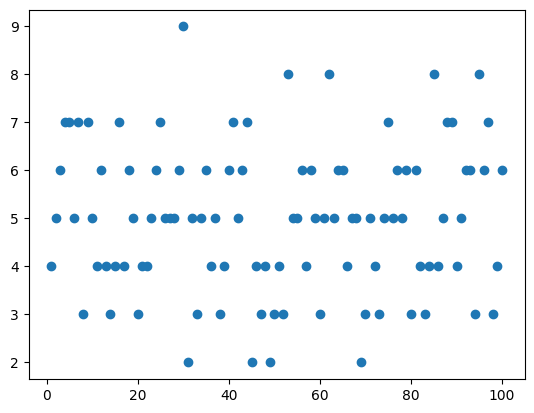

In [17]:
plt.scatter(np.arange(1,101), np.random.binomial(10,0.5,100))


In [24]:

data=np.random.binomial(10,0.5,100)

val=np.sum(data)/100

np.sum((data-val)**2)


255.39000000000001

In [ ]:
data-val

array([ 0.81, -1.19, -2.19, -2.19, -0.19, -0.19, -0.19, -1.19,  0.81,
       -1.19, -1.19, -2.19,  1.81,  0.81, -1.19,  2.81,  1.81,  0.81,
       -2.19,  0.81,  0.81, -1.19, -1.19, -1.19,  1.81,  1.81, -0.19,
       -2.19,  0.81, -0.19,  1.81,  0.81,  1.81, -2.19, -0.19,  0.81,
       -1.19,  1.81, -0.19,  0.81, -0.19, -0.19, -0.19, -2.19, -3.19,
        1.81, -2.19, -1.19,  2.81,  2.81, -2.19, -0.19, -0.19, -1.19,
        0.81, -0.19,  0.81,  3.81, -1.19, -0.19, -0.19,  0.81, -0.19,
        1.81, -0.19,  0.81, -0.19,  2.81, -2.19,  1.81,  1.81, -0.19,
        0.81,  4.81, -1.19, -3.19,  0.81,  2.81, -1.19, -3.19,  1.81,
       -1.19, -1.19, -1.19,  1.81, -0.19,  1.81, -0.19, -2.19,  0.81,
       -1.19, -1.19, -1.19, -1.19, -1.19,  1.81,  0.81, -1.19,  0.81,
       -0.19])

In [ ]:
np.sum(((data-val)**2))

2.5538999999999996

In [25]:
np.var(data)

2.5539

In [38]:
p=sp.symbols('p')
n=sp.symbols('x',real=True,positive=True)
# 1/(1-p)
r=sp.Sum(p*(1-p)**(n-1),(n,0,n))
r


Sum(p*(1 - p)**(x - 1), (x, 0, x))

In [ ]:
rf=r.diff(p)


(p*x*(1 - p)**x/(1 - p) - (1 - p)**x/(1 - p))/(p - 1)

In [ ]:
l=1/(1-p)
lf=l.diff(p)
sp.pprint(df)



   1    
────────
       2
(1 - p) 


In [4]:
# 累加下标提取
# 声明变量为正数，避免 Piecewise 出现
y, p = sp.symbols('y p', positive=True)
# 声明 m 为正整数，i 为求和的整数索引
m = sp.symbols('m', integer=True, positive=True)
i = sp.symbols('i', integer=True)
# 提取系数和内部求和项
coefficient = p / (p + y)
term = (y / (p + y))**(i - 1)

# 构造从 i=m 到无穷大的求和
s = sp.Sum(term, (i, m, sp.oo))

# 乘以系数并化简
final_expr = sp.simplify(coefficient * s.doit())
final_expr

⎧ m - 1        1 - m         y      
⎪y     ⋅(p + y)        for ───── < 1
⎪                          p + y    
⎪                                   
⎪    ∞                              
⎪   ___                             
⎪   ╲                               
⎨    ╲    i        -i               
⎪p⋅  ╱   y ⋅(p + y)                 
⎪   ╱                               
⎪   ‾‾‾                             
⎪  i = m                            
⎪────────────────────    otherwise  
⎪         y                         
⎩                                   

In [17]:
# 负二项式定理


x,r=sp.symbols('x,r',real=True,positive=True,integer=True)
f=(1-x)**r

sp.series(f,x)

In [ ]:
k,p=sp.symbols('k,p')
expr=sp.binomial(k+r-1,k)*(p**k)

se=sp.Sum(expr,(k,0,r))#sp.oo设置好后再调用doit会直接调用内部引擎
expand=sp.binomial(0+r-1,k)*(p**k).subs(k,0)
for _ in range(1,6):
    expand=expand+sp.binomial(_+r-1,_)*(p**k).subs(k,_)
    
expand

In [40]:
sp.binomial(_+r-1,_).rewrite(sp.factorial)

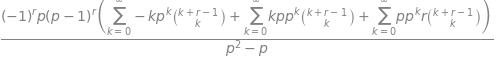

In [ ]:
sum_expr=sp.Sum(sp.binomial(k+r-1,k)*(p**k)*(1-p)**r,(k,0,sp.oo))
sp.factor(sum_expr.diff(p)*p)


In [59]:
# 提取Sum里的表达式
sum_expr.function